In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

# ── 1. Load data ─────────────────────────────────────────────────
df_bind = pd.read_excel('../data/单金属原子在石墨烯上的结合能和扩散势垒.xlsx')
df_bind_g = df_bind.groupby('Metal')[['Binding', 'Diffusion']].mean().reset_index()

df_aff = pd.read_excel("../data/负载金属M对O的亲和性QMO以及对载体金属的亲和性QMM'.xlsx")
df_aff = df_aff.rename(columns={df_aff.columns[1]: 'QMO'})

df_nps = pd.read_excel('./NPs.xlsx')
df_nps = df_nps.rename(columns={'反应后MOF表面是否有纳米粒子': 'ExternalNP'})
df_nps['MOF'] = df_nps['MOF'].ffill()

# Define your renaming dictionary
mof_rename_dict = {

}

# Apply the replacement
df_nps["MOF"] = df_nps["MOF"].replace(mof_rename_dict)


df_mof = pd.read_csv('../data/MOF_factor.csv').reset_index(drop = True)
# Optional: check for consistency with df_mof
for i in df_nps["MOF"]:
    assert i in list(df_mof["MOF"]), f"{i} not in df_mof"

# ── 2. Merge all descriptors ─────────────────────────────────────
df = (
    df_nps
    .merge(df_mof, on='MOF', how='left')
    .merge(df_bind_g.rename(columns={'Binding': 'BindingEnergy', 'Diffusion': 'DiffusionBarrier'}),
           left_on='M', right_on='Metal', how='left')
    .merge(df_aff[['Metal', 'QMO']], left_on='M', right_on='Metal', how='left')
    .drop(columns=['Metal', 'Metal_aff'], errors='ignore')
)

df = df.dropna(subset=['BindingEnergy', 'DiffusionBarrier', 'QMO'])
df = df.drop(columns=['Metal_x', 'Metal_y'], errors='ignore')

noble_set = {'Au', 'Ag', 'Pt', 'Pd', 'Ir', 'Rh', 'Ru'}
df['Noble'] = df['M'].apply(lambda x: 1 if x in noble_set else 0)

<Figure size 800x500 with 0 Axes>

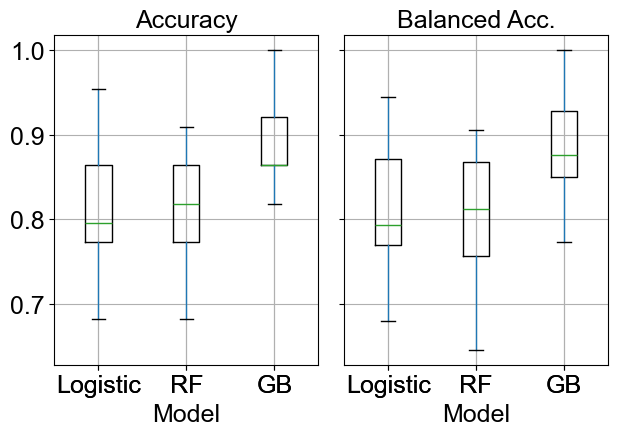

In [2]:
# ML inputs
y = df['ExternalNP'].astype(int)
X = df.drop(columns=['ExternalNP', 'M', 'MOF',
                     'ICP-OES', '反应后是否有pxrd信号',
                     '苯乙烯加氢产率', "MOF_indexs", "Unnamed: 0"], errors='ignore')
X = X.dropna(axis=1)
X = X.loc[:, X.nunique() > 1]

feature_names = X.columns

# ────────────────────────────────────────────────────────────────
# 2. LOOP OVER RANDOM SPLITS, COLLECT METRICS & IMPORTANCES
# ────────────────────────────────────────────────────────────────
n_splits = 24
metrics = []
coeff_mat = []
rf_imp_mat = []
gb_imp_mat = []

for seed in range(n_splits):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)

    # Logistic with scaling pipeline
    log_pipe = Pipeline([
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000))
    ])
    log_pipe.fit(X_train, y_train)

    rf = RandomForestClassifier(n_estimators=400, random_state=seed)
    rf.fit(X_train, y_train)

    gb = GradientBoostingClassifier(random_state=seed)
    gb.fit(X_train, y_train)

    # Predictions / metrics
    for name, model in zip(['Logistic', 'RF', 'GB'],
                           [log_pipe, rf, gb]):
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        bal = balanced_accuracy_score(y_test, pred)
        metrics.append({'Model': name, 'Seed': seed, 'Accuracy': acc, 'Balanced Acc.': bal})

    # Save importances
    coeff_mat.append(np.abs(log_pipe.named_steps['clf'].coef_[0]))
    rf_imp_mat.append(rf.feature_importances_)
    gb_imp_mat.append(gb.feature_importances_)

# Metrics DF
metrics_df = pd.DataFrame(metrics)

# ────────────────────────────────────────────────────────────────
# 3. PLOT ACCURACY + BALANCED ACCURACY BOXPLOTS
# ────────────────────────────────────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# 3. PLOT ACCURACY + BALANCED ACCURACY BOXPLOTS
# ────────────────────────────────────────────────────────────────

order = ['Logistic', 'RF', 'GB']
metrics_df['Model'] = pd.Categorical(metrics_df['Model'],
                                     categories=order,
                                     ordered=True)

boxprops   = dict(linewidth=1)
flierprops = dict(marker='o', markersize=4, markerfacecolor='none')

with plt.rc_context({
    "font.family": "Arial",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 18
}):
    fig = plt.figure(figsize=(8, 5))
    
    axes = metrics_df.boxplot(
        by='Model',
        column=['Accuracy', 'Balanced Acc.'],  # make sure this matches your col name
        boxprops=boxprops,
        flierprops=flierprops,
        showfliers=False
    )

    plt.ylabel('Score')
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig("./acc_vs_balanced.png", dpi=600, bbox_inches='tight')
    plt.show()

# ────────────────────────────────────────────────────────────────
# 4. AVERAGE FEATURE IMPORTANCE ACROSS SPLITS
# ────────────────────────────────────────────────────────────────
coeff_avg = np.mean(coeff_mat, axis=0)
rf_avg = np.mean(rf_imp_mat, axis=0)
gb_avg = np.mean(gb_imp_mat, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Logistic': coeff_avg,
    'RF': rf_avg,
    'GB': gb_avg
})

# Normalise each column to 1 for comparability
importance_df[['Logistic','RF','GB']] = \
    importance_df[['Logistic','RF','GB']].div(
        importance_df[['Logistic','RF','GB']].max())

In [3]:
# Per-model mean and std for Accuracy and Balanced
summary_by_model = metrics_df.groupby('Model')[['Accuracy', 'Balanced Acc.']].agg(['mean', 'std'])

print(summary_by_model)

          Accuracy           Balanced Acc.          
              mean       std          mean       std
Model                                               
Logistic  0.810606  0.073007      0.809117  0.071561
RF        0.821970  0.062750      0.806624  0.069473
GB        0.886364  0.056868      0.884615  0.058201


C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_55548\4037479693.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_by_model = metrics_df.groupby('Model')[['Accuracy', 'Balanced Acc.']].agg(['mean', 'std'])


In [4]:
len(X)

110

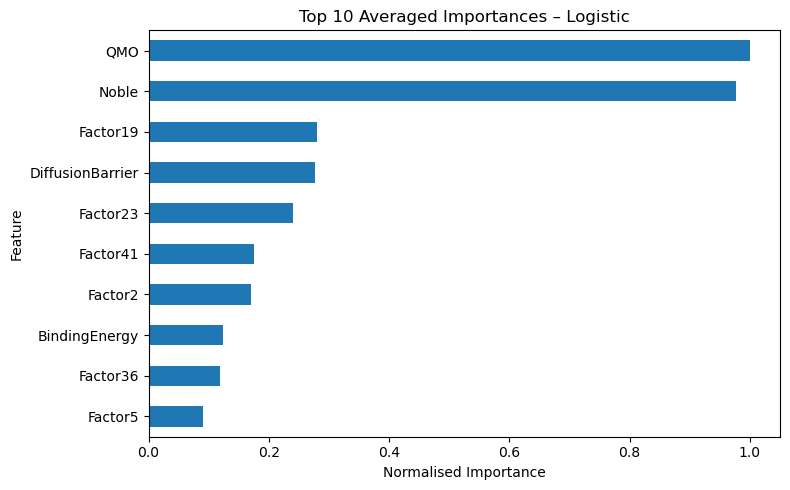

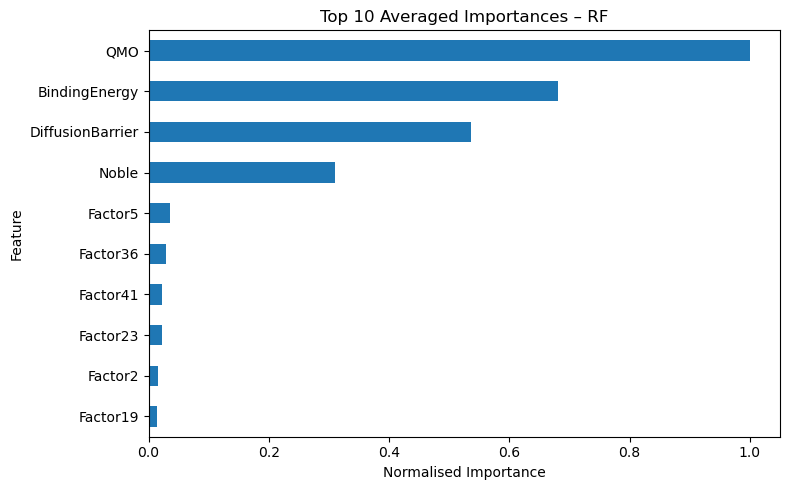

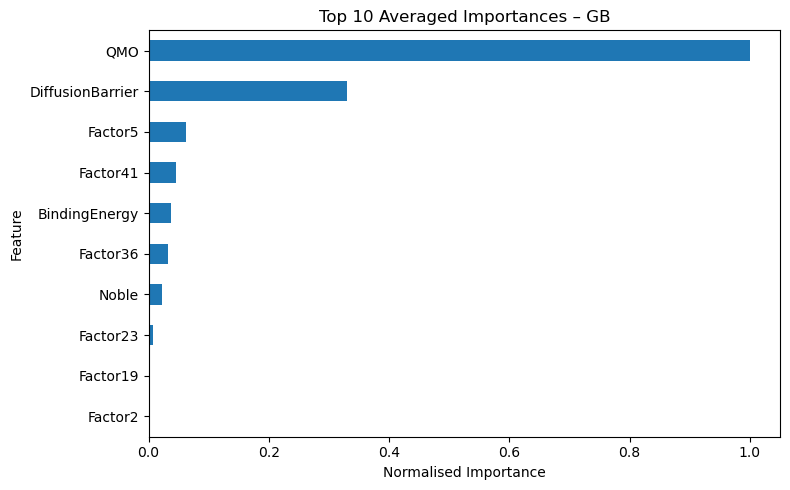

In [5]:
# Top 10 by mean rank
importance_df['MeanRank'] = importance_df[['Logistic','RF','GB']].mean(axis=1)
top_imp = importance_df.sort_values('MeanRank', ascending=False).head(10)

# Plot per‑model averaged importances
for col in ['Logistic','RF','GB']:
    plt.figure(figsize=(8,5))
    top_imp.set_index('Feature')[col].sort_values().plot(kind='barh')
    plt.title(f'Top 10 Averaged Importances – {col}')
    plt.xlabel('Normalised Importance')
    plt.tight_layout()
    plt.show()

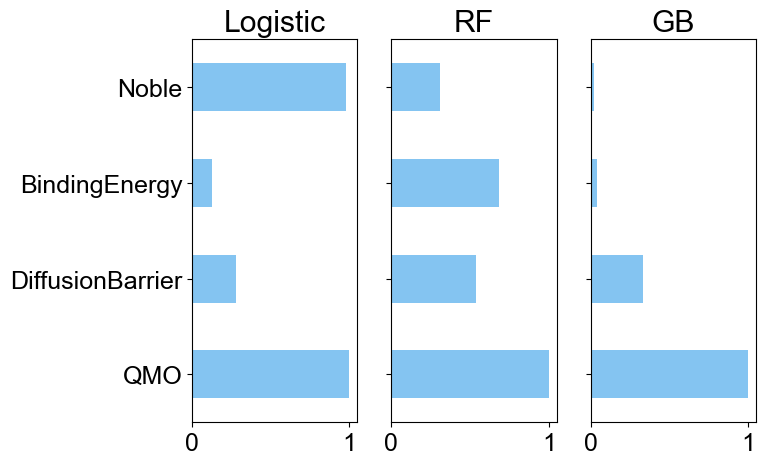

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Font: Arial ────────────────────────────────────────────────
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18  # tweak if you want larger

# Metal descriptors of interest
metal_features = ['QMO', 'DiffusionBarrier', 'BindingEnergy', 'Noble']

# Subset to those
metal_imp = importance_df[importance_df['Feature'].isin(metal_features)].copy()

# Enforce a consistent feature order
feat_order = ['QMO', 'DiffusionBarrier', 'BindingEnergy', 'Noble']
metal_imp['Feature'] = pd.Categorical(
    metal_imp['Feature'],
    categories=feat_order,
    ordered=True
)
metal_imp = metal_imp.sort_values('Feature')

models = ['Logistic', 'RF', 'GB']

# Choose bar colors per model
model_colors = {
    'Logistic': "#84c4f1",  # blue-ish
    'RF':       '#84c4f1',  # green-ish
    'GB':       '#84c4f1',  # red-ish
}

fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharey=True)

for ax, col in zip(axes, models):
    (
        metal_imp
        .set_index('Feature')[col]
        .reindex(feat_order)          # keep same order in all panels
        .plot(kind='barh',
              ax=ax,
              color=model_colors[col])  # <- bar color
    )
    ax.set_title(col)

# Remove axis labels, keep tick labels
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig('./metal_descriptors_importance_bars.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# ML inputs
y = df['ExternalNP'].astype(int)
X = df.drop(columns=['ExternalNP', 'M', 'MOF',
                     'ICP-OES', '反应后是否有pxrd信号',
                     '苯乙烯加氢产率', "MOF_index", "Unnamed: 0"], errors='ignore')
X = X.dropna(axis=1)
X = X.loc[:, X.nunique() > 1]

feature_names = X.columns

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------
# parameters
# ---------------------------------------------------------------
n_splits            = 24            # same as your metrics loop
n_features_to_keep  = 8            # RFE keeps this many each split

# ---------------------------------------------------------------
# storage
# ---------------------------------------------------------------
select_counts = pd.Series(0, index=feature_names, dtype=int)

# ---------------------------------------------------------------
# RFE across random splits
# ---------------------------------------------------------------
for seed in range(n_splits):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)

    # scale ALL predictors for logistic‑RFE
    scaler   = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)

    base_lr  = LogisticRegression(max_iter=2000, random_state=seed)
    rfe      = RFE(estimator=base_lr,
                   n_features_to_select=n_features_to_keep,
                   step=1)
    rfe.fit(X_train_s, y_train)

    # update counts
    select_counts[rfe.support_] += 1

# ---------------------------------------------------------------
# summarise selection frequency
# ---------------------------------------------------------------
freq_df = (
    select_counts
      .to_frame('TimesSelected')
      .assign(Frequency=lambda s: s['TimesSelected'] / n_splits)
      .sort_values('TimesSelected', ascending=False)
)

print("\n=== RFE‑stable features (ranked) ===")
print(freq_df.head(20).to_string())

# ---------------------------------------------------------------
# quick bar‑plot of top 20
# ---------------------------------------------------------------
freq_df.head(20)['Frequency'].sort_values().plot(
    kind='barh', figsize=(6,6), title='RFE selection frequency')
plt.xlabel(f'Fraction of {n_splits} splits selected')
plt.tight_layout()
plt.show()